## 로지스틱 회귀분석 

In [13]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/전처리완료.csv")

### 1. 데이터 분할하기

In [14]:
# 데이터 분리 라이브러리
from sklearn.model_selection import train_test_split

# 특징 변수(X)와 목표 변수(y) 분리
X = df.drop('고객이탈여부', axis=1)
y = df['고객이탈여부']

# 학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
y.value_counts()

고객이탈여부
0    7963
1    2037
Name: count, dtype: int64

In [16]:
print(y_train.value_counts())
print(y_test.value_counts())

고객이탈여부
0    6356
1    1644
Name: count, dtype: int64
고객이탈여부
0    1607
1     393
Name: count, dtype: int64


### 2. 데이터 정규화 하기

In [17]:
# 연속형 데이터 정규화
from sklearn.preprocessing import StandardScaler

# 연속형 열 선택
numeric_features = ['신용점수', '나이', '계좌잔액', '근속기간', '추정연봉']

# 정규화 객체 생성
scaler = StandardScaler()

# 훈련데이터에 수치형 데이터 정규화
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])

# test data를 훈련데이터에 맞게 정규화 적용
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

### 3. 로지스틱 회귀모델 구현

#### 1) 예측하기

In [18]:
# 라이브러리 불러오기
from sklearn.linear_model import LogisticRegression

# 로지스틱 회귀 모델 학습
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# 예측
y_pred = log_reg.predict(X_test)

y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

#### 2) 평가하기

In [19]:
# 성과평가 라이브러리 불러오기
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import roc_curve, roc_auc_score

# 평가
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall", recall_score(y_test, y_pred))
print("f1_score", f1_score(y_test, y_pred))


Accuracy: 0.815
Precision: 0.5966386554621849
Recall 0.1806615776081425
f1_score 0.27734375


In [20]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[1559   48]
 [ 322   71]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.97      0.89      1607
           1       0.60      0.18      0.28       393

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [21]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.83      0.97      0.89      1607\n           1       0.60      0.18      0.28       393\n\n    accuracy                           0.81      2000\n   macro avg       0.71      0.58      0.59      2000\nweighted avg       0.78      0.81      0.77      2000\n'

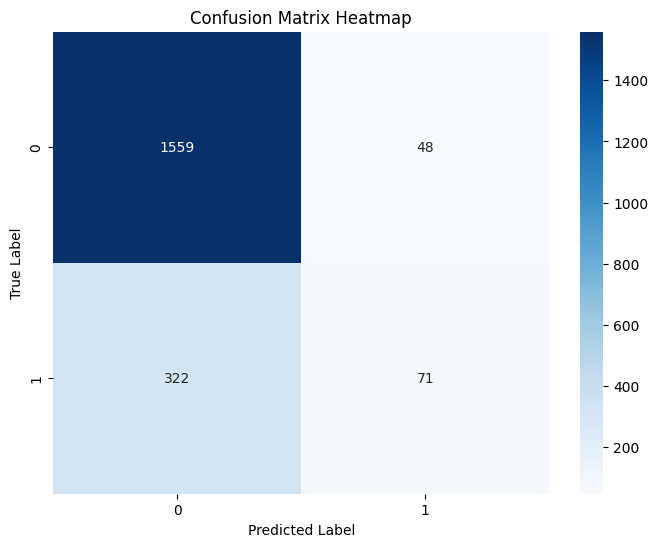

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#### 3) ROC커브 그리기

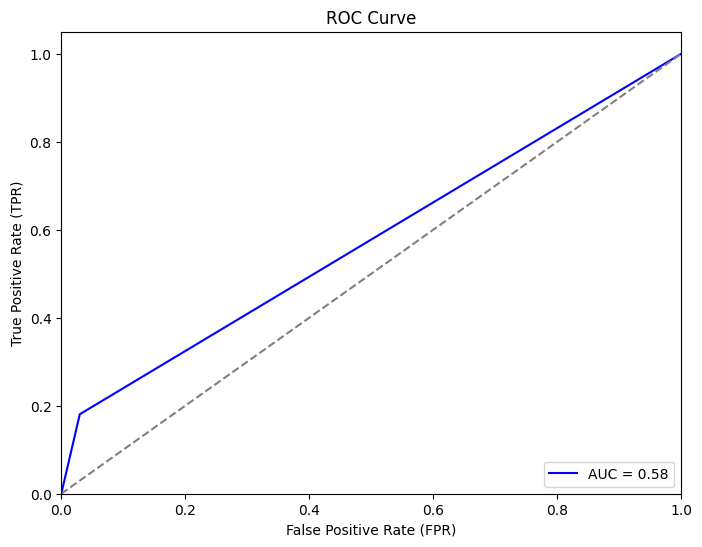

In [23]:
import matplotlib.pyplot as plt

# ROC 커브를 그리기 위한 FPR, TPR 계산
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

# ROC 커브 그래프 그리기
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # 대각선 기준선
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

### 4. 로지스틱 회귀모델 유의성 검정하기

In [24]:
import statsmodels.api as sm

logreg = sm.Logit(y_train, X_train).fit()
logreg.summary()

Optimization terminated successfully.
         Current function value: 0.441181
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 고객이탈여부   No. Observations:                 8000
Model:                          Logit   Df Residuals:                     7990
Method:                           MLE   Df Model:                            9
Date:                Wed, 25 Sep 2024   Pseudo R-squ.:                  0.1314
Time:                        10:51:23   Log-Likelihood:                -3529.5
converged:                       True   LL-Null:                       -4063.5
Covariance Type:            nonrobust   LLR p-value:                3.668e-224
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
신용점수          -0.0632      0.030     -2.129      0.033      -0.121      -0.005
국가             0.0451      0.036      1.269      0.204      -0.025       0.115
성별            -0.6687      0.057    -11.689      0.000      -0.781      -0.557
나이             0.7500      0.030     25.203      0.000       0.692       0.808
근속기간          -0.0370      0.030     -1.247      0.212      -0.095       0.021
계좌잔액           0.2541      0.031      8.149      0.000       0.193       0.315
사용중인상품수       -0.3292      0.035     -9.314      0.000      -0.398      -0.260
신용카드보유여부      -0.2103      0.058     -3.639      0.000      -0.324      -0.097
활성회원여부        -1.1738      0.062    -18.915      0.000      -1.295      -1.052
추정연봉           0.0194      0.030      0.647      0.518      -0.039       0.078
==============================================================================
"""

In [25]:
import statsmodels.api as sm

logreg = sm.Logit(y_train, X_train.drop(['추정연봉','성별','근속기간','국가'], axis=1)).fit()
logreg.summary()

Optimization terminated successfully.
         Current function value: 0.450064
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 고객이탈여부   No. Observations:                 8000
Model:                          Logit   Df Residuals:                     7994
Method:                           MLE   Df Model:                            5
Date:                Wed, 25 Sep 2024   Pseudo R-squ.:                  0.1139
Time:                        10:51:23   Log-Likelihood:                -3600.5
converged:                       True   LL-Null:                       -4063.5
Covariance Type:            nonrobust   LLR p-value:                6.601e-198
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
신용점수          -0.0562      0.029     -1.916      0.055      -0.114       0.001
나이             0.7469      0.029     25.328      0.000       0.689       0.805
계좌잔액           0.2197      0.030      7.228      0.000       0.160       0.279
사용중인상품수       -0.4548      0.031    -14.452      0.000      -0.516      -0.393
신용카드보유여부      -0.3054      0.056     -5.449      0.000      -0.415      -0.196
활성회원여부        -1.2237      0.061    -19.968      0.000      -1.344      -1.104
==============================================================================
"""

### 5. 유의하지 않은 변수 제거한 뒤 성능평가 해보기

In [26]:
X_train_mod = X_train.drop(['추정연봉','성별','근속기간','국가'], axis=1)
X_test_mod = X_test.drop(['추정연봉','성별','근속기간','국가'], axis=1)

# 라이브러리 불러오기
from sklearn.linear_model import LogisticRegression

# 로지스틱 회귀 모델 학습
log_reg = LogisticRegression()
log_reg.fit(X_train_mod, y_train)

# 예측
y_pred = log_reg.predict(X_test_mod)

y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [27]:
# 성과평가 라이브러리 불러오기
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import roc_curve, roc_auc_score

# 평가
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall", recall_score(y_test, y_pred))
print("f1_score", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8105
Precision: 0.5660377358490566
Recall 0.15267175572519084
f1_score 0.24048096192384769
Confusion Matrix:
 [[1561   46]
 [ 333   60]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.97      0.89      1607
           1       0.57      0.15      0.24       393

    accuracy                           0.81      2000
   macro avg       0.70      0.56      0.57      2000
weighted avg       0.77      0.81      0.76      2000



In [28]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[1561   46]
 [ 333   60]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.97      0.89      1607
           1       0.57      0.15      0.24       393

    accuracy                           0.81      2000
   macro avg       0.70      0.56      0.57      2000
weighted avg       0.77      0.81      0.76      2000



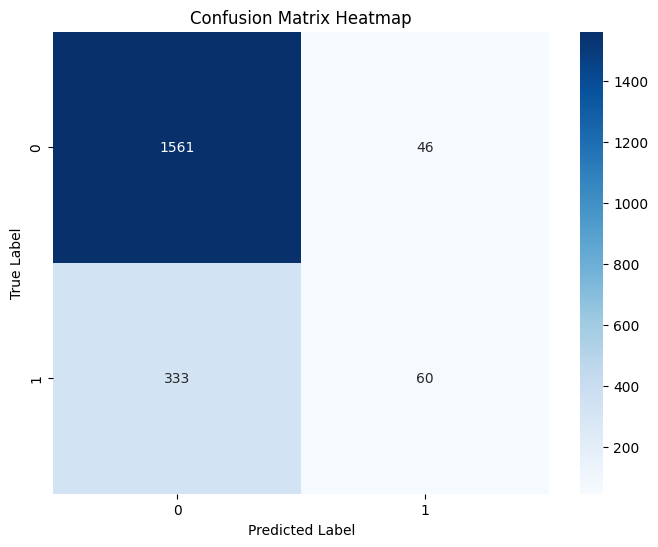

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

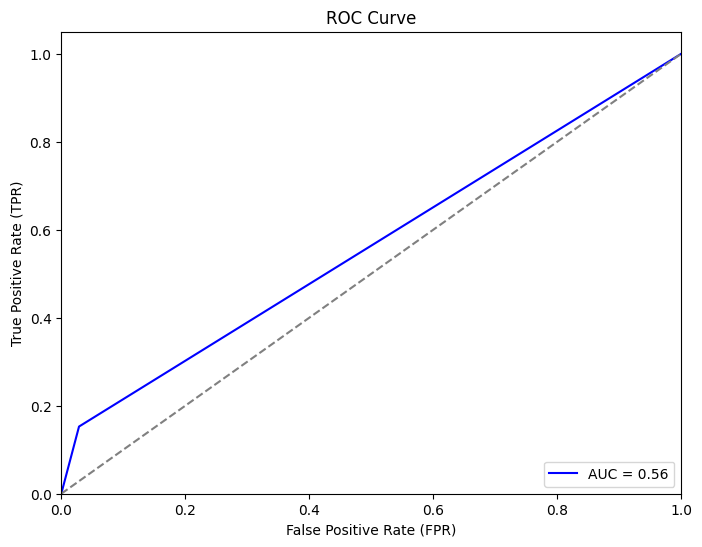

In [30]:
import matplotlib.pyplot as plt

# ROC 커브를 그리기 위한 FPR, TPR 계산
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

# ROC 커브 그래프 그리기
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # 대각선 기준선
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()